## What problem does it solve?

Linear Regression predicts a continuous numerical value.

Examples:

- House price prediction
- Sales forecasting
- Temperature prediction
- Insurance cost prediction

If the output is a number, Linear Regression is usually the first baseline model.

The most common cost function is Mean Squared Error. - MSE is differentiable and easier for optimization.

Why does Linear Regression work?

What is MSE?

What is Gradient Descent (high level)?

What is multicollinearity?

What is R² vs Adjusted R²?

What are residuals?

What is underfitting vs overfitting?

When would you choose Linear Regression over Random Forest?


Assumptions of Linear Regression

1. Linear Relationship -
Input and output should have roughly linear relation.

2. Independence of Observations - 
Each row should be independent.

3. Homoscedasticity - 
Residuals should have constant variance.

4. No Multicollinearity - 
Features should not strongly depend on each other.

5. Residuals should be approximately normal - 
Important for statistical interpretation.


Linear Regression typically has - Higher Bias   Lower Variance

When should you use Linear Regression?

Use when:

✅ Relationship is roughly linear

✅ Explainability matters

✅ Small dataset

✅ Fast baseline needed

When should you NOT use it?

Avoid when:

❌ Relationship is highly nonlinear

❌ Complex interactions exist

❌ Data contains many outliers

❌ Feature interactions dominate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
file_path = r"C:\Users\atalb\Documents\Coding\MLandAI\ML-Revision\ml-algorithms\Datasets\insurance.csv"
df = pd.read_csv(file_path)
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.isnull().sum()

index       0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [12]:
gender_map = {'male': 0, 'female': 1}
df['sex'] = df['sex'].map(gender_map)

region_map = {'southeast': 0, 'southwest': 1, 'northwest': 2, 'northeast': 3}
df['region'] = df['region'].map(region_map)

smoker_map = {'yes': 1, 'no': 0}
df['smoker'] = df['smoker'].map(smoker_map)
df.head()

,index,age,sex,bmi,children,smoker,region,charges
0,0,19,1,27.900,0,1,1,16884.92400
1,1,18,0,33.770,1,0,0,1725.55230
2,2,28,0,33.000,3,0,0,4449.46200
3,3,33,0,22.705,0,0,2,21984.47061
4,4,32,0,28.880,0,0,2,3866.85520


In [14]:
corr_matrix = df.corr()

<Axes: >

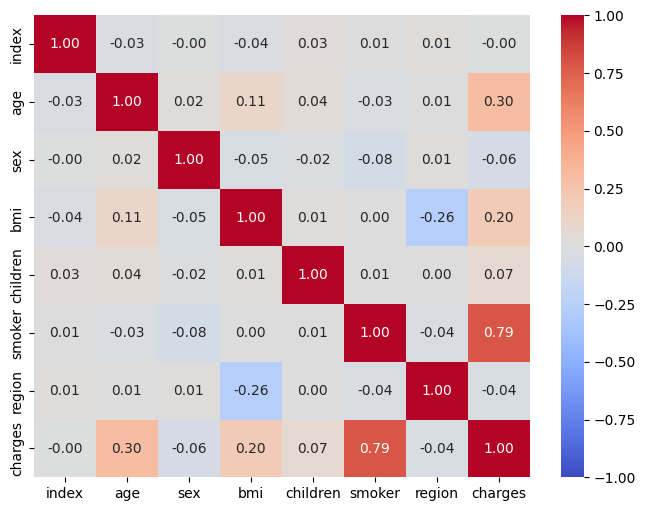

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  # Shows the correlation numbers inside the squares
    cmap="coolwarm",  # Colors: Red for positive, Blue for negative correlation
    fmt=".2f",  # Limits decimal places to 2
    vmin=-1,
    vmax=1,  # Anchors the color bar scale from -1 to 1
)

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 7)
y_train shape: (1070,)
X_test shape: (268, 7)
y_test shape: (268,)


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 33757442.66781989
R-squared: 0.7825589791076093


# Linear Regression Interview Revision

## Why does Linear Regression work?

Linear Regression works because it assumes that the target variable can be approximated as a linear combination of input features.

Mathematically:

y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

The algorithm learns the optimal coefficients (weights) that minimize the prediction error on the training data.

It is effective when:

- There is a roughly linear relationship between features and target.
- The signal in the data is stronger than the noise.
- The assumptions of linear regression are reasonably satisfied.

---

## What is MSE?

MSE (Mean Squared Error) is a metric used to measure how far predictions are from actual values.

Formula:

MSE = (1/n) × Σ(y_actual - y_predicted)²

### Why square the errors?

- Prevents positive and negative errors from canceling each other.
- Penalizes large errors more heavily than small errors.
- Produces a differentiable function that is easy to optimize.

### Interpretation

- Lower MSE = Better model.
- MSE = 0 means perfect predictions.

---

## What is Gradient Descent? (High Level)

Gradient Descent is an optimization algorithm used to find the values of model parameters that minimize the cost function.

Process:

1. Start with random weights.
2. Calculate prediction error.
3. Compute the gradient (direction of steepest increase).
4. Move in the opposite direction of the gradient.
5. Repeat until the error stops decreasing significantly.

### Intuition

Imagine standing on a hill blindfolded and trying to reach the lowest point.

At each step, you move in the direction that goes downhill the fastest.

That is essentially what Gradient Descent does.

---

## What is Multicollinearity?

Multicollinearity occurs when two or more independent variables are highly correlated with each other.

Example:

- Area in square feet
- Area in square meters

Both contain nearly the same information.

### Problems caused by multicollinearity

- Unstable coefficients
- Difficult interpretation of feature importance
- Small changes in data can cause large coefficient changes

### How to detect it?

- Correlation matrix
- Variance Inflation Factor (VIF)

### How to fix it?

- Remove redundant features
- Combine correlated features
- Use regularization techniques

---

## What is R² vs Adjusted R²?

### R² (Coefficient of Determination)

R² measures how much variance in the target variable is explained by the model.

Formula:

R² = 1 - (Residual Sum of Squares / Total Sum of Squares)

### Interpretation

- R² = 1 → Perfect fit
- R² = 0 → Model explains no variance
- Higher R² is generally better

### Problem with R²

R² never decreases when new features are added, even if those features are useless.

---

### Adjusted R²

Adjusted R² introduces a penalty for adding unnecessary features.

Benefits:

- Rewards useful features.
- Penalizes irrelevant features.
- Better metric when comparing models with different numbers of features.

### Interview Answer

Use R² to understand explanatory power and Adjusted R² when evaluating models with multiple features.

---

## What are Residuals?

Residuals are the differences between actual values and predicted values.

Formula:

Residual = Actual Value - Predicted Value

### Example

Actual Price = ₹50 lakh

Predicted Price = ₹47 lakh

Residual = ₹3 lakh

### Why are residuals important?

Residual analysis helps identify:

- Model bias
- Non-linearity
- Outliers
- Violations of assumptions

A good model should have residuals randomly distributed around zero.

---

## What is Underfitting vs Overfitting?

### Underfitting

The model is too simple and fails to capture patterns in the data.

Characteristics:

- High bias
- Poor training performance
- Poor test performance

Example:

Using a straight line to model a highly curved relationship.

---

### Overfitting

The model learns noise and specific details of the training data instead of general patterns.

Characteristics:

- Low bias
- High variance
- Excellent training performance
- Poor test performance

Example:

A very deep decision tree that memorizes training samples.

---

### Goal

Build a model that balances bias and variance and generalizes well to unseen data.

---

## When would you choose Linear Regression over Random Forest?

Choose Linear Regression when:

### 1. Interpretability is important

Linear Regression clearly shows how each feature affects the prediction through coefficients.

Example:

- How much does area impact house price?
- How much does experience impact salary?

Random Forest does not provide this level of transparency.

---

### 2. Relationship is approximately linear

If the relationship between features and target is mostly linear, Linear Regression can perform surprisingly well.

---

### 3. Small datasets

Linear Regression often performs better on smaller datasets because it has fewer parameters and lower variance.

---

### 4. Fast training and inference are required

Linear Regression trains and predicts much faster than Random Forest.

---

### 5. Statistical inference is needed

Linear Regression provides:

- Coefficients
- Confidence intervals
- P-values

These are useful in research and business analysis.

---

### When would Random Forest be preferred?

Choose Random Forest when:

- Relationships are highly nonlinear.
- Feature interactions are important.
- Data contains complex patterns.
- Predictive accuracy is more important than interpretability.

### Interview Summary

Use Linear Regression when explainability, simplicity, and speed are important.

Use Random Forest when accuracy and modeling complex nonlinear relationships are the primary goals.